### 1. Using Python, load the text book “The Adventures of Huckleberry Finn”   directly from the web into lists of chapters.


In [4]:
! pip install requests beautifulsoup4 pandas

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import requests
import re
import pandas as pd

# Load the full text
url = "https://www.gutenberg.org/files/76/76-0.txt"
response = requests.get(url)
text = response.text

# Strip Project Gutenberg header/footer
start_index = text.find("CHAPTER I.")
end_index = text.rfind("THE END.") + len("THE END.")
text = text[start_index:end_index]

# Split into chapters using CHAPTER [ROMAN NUMERAL].
chapters = re.split(r'(CHAPTER\s+[IVXLCDM]+\.)', text)

# Recombine headings + content
chapter_texts = []
for i in range(1, len(chapters), 2):
    title = chapters[i].strip()
    content = chapters[i+1].strip()
    chapter_texts.append(f"{title}\n{content}")

### 2. Place them into a table to see how each chapter begins. 


In [6]:
df = pd.DataFrame({
    "Chapter Number": [f"Chapter {i+1}" for i in range(len(chapter_texts))],
    "Text": chapter_texts
})
df.head()

,Chapter Number,Text
0,Chapter 1,CHAPTER I.\nCivilizing Huck.—Miss Watson.—Tom ...
1,Chapter 2,CHAPTER II.\nThe Boys Escape Jim.—Torn Sawyer’...
2,Chapter 3,CHAPTER III.\nA Good Going-over.—Grace Triumph...
3,Chapter 4,CHAPTER IV.\nHuck and the Judge.—Superstition.
4,Chapter 5,CHAPTER V.\nHuck’s Father.—The Fond Parent.—Re...


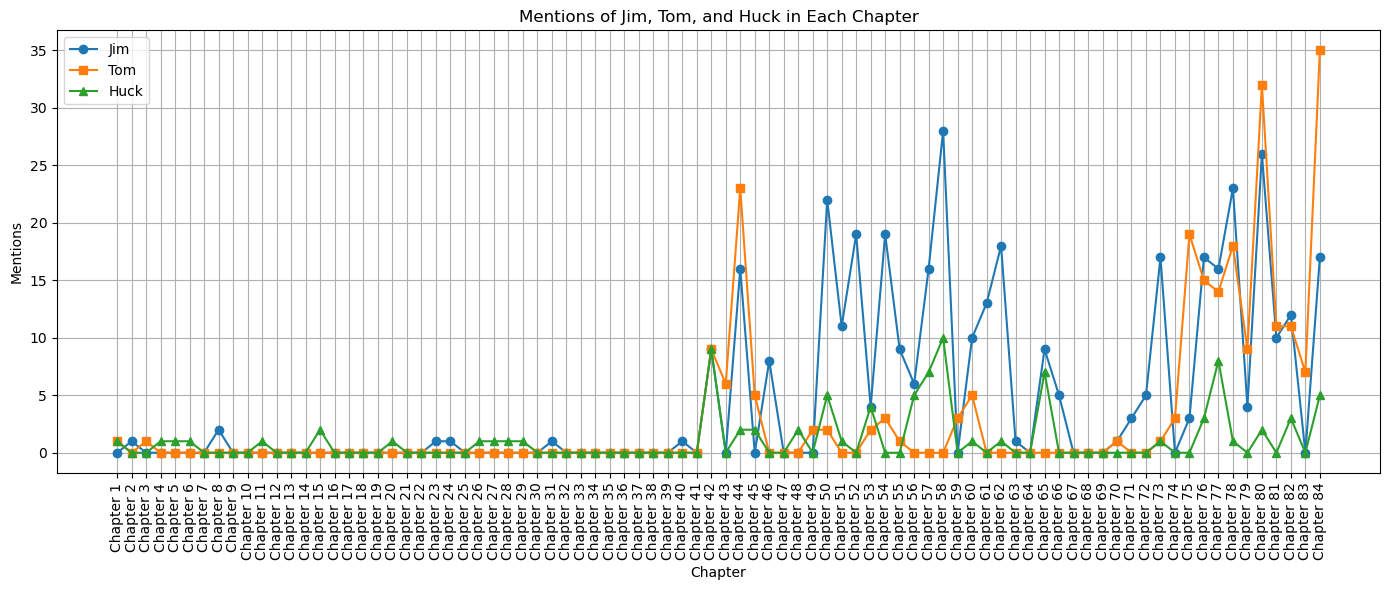

In [7]:
import matplotlib.pyplot as plt
import re

# Count mentions (case-insensitive match with word boundaries)
df['Jim'] = df['Text'].str.count(r'\bJim\b', flags=re.IGNORECASE)
df['Tom'] = df['Text'].str.count(r'\bTom\b', flags=re.IGNORECASE)
df['Huck'] = df['Text'].str.count(r'\bHuck\b', flags=re.IGNORECASE)

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(df['Chapter Number'], df['Jim'], label='Jim', marker='o')
plt.plot(df['Chapter Number'], df['Tom'], label='Tom', marker='s')
plt.plot(df['Chapter Number'], df['Huck'], label='Huck', marker='^')

plt.xlabel('Chapter')
plt.ylabel('Mentions')
plt.title('Mentions of Jim, Tom, and Huck in Each Chapter')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


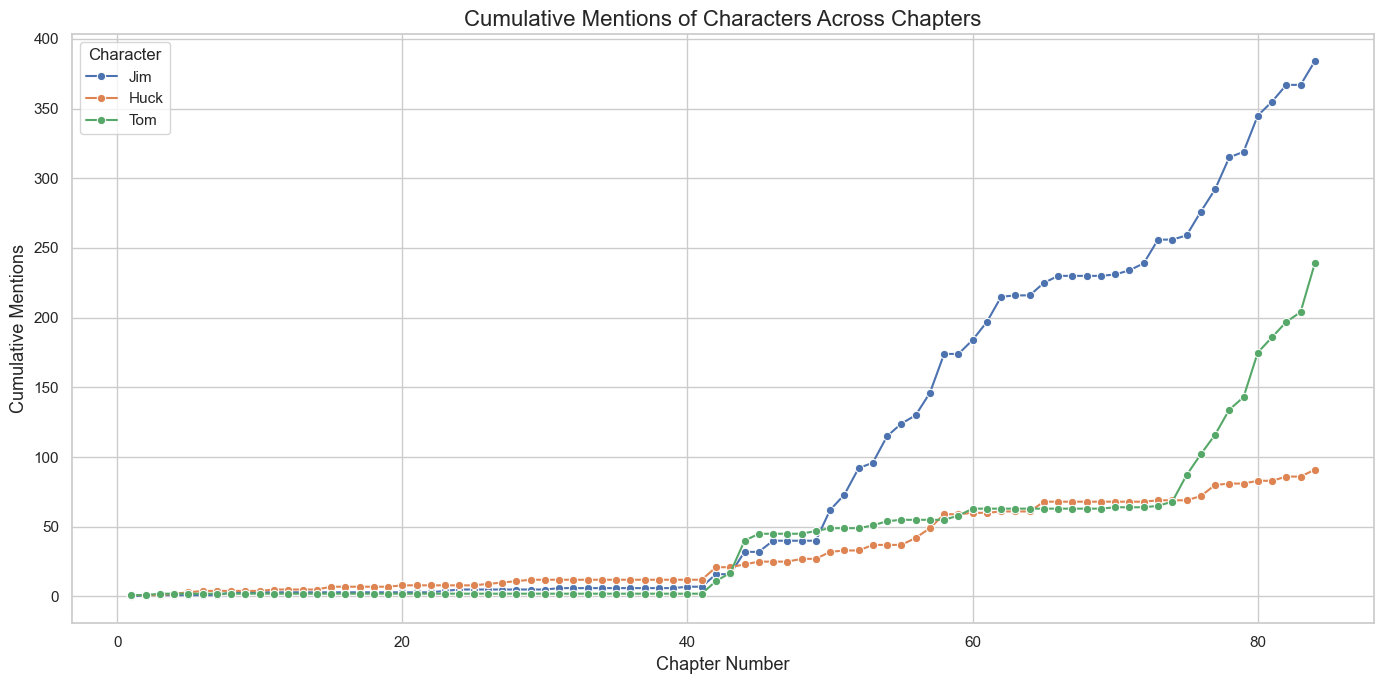

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'Chapter Number' to string first to avoid AttributeError
df['Chapter Number'] = df['Chapter Number'].astype(str).str.extract(r'(\d+)').astype(int)

# Sort chapters
df = df.sort_values('Chapter Number')

# Calculate cumulative mentions
df['Cumulative Jim'] = df['Jim'].cumsum()
df['Cumulative Huck'] = df['Huck'].cumsum()
df['Cumulative Tom'] = df['Tom'].cumsum()

# Melt for seaborn
df_melted = df.melt(id_vars='Chapter Number', 
                    value_vars=['Cumulative Jim', 'Cumulative Huck', 'Cumulative Tom'],
                    var_name='Character', value_name='Cumulative Mentions')

# Clean character labels
df_melted['Character'] = df_melted['Character'].str.replace('Cumulative ', '')

# Seaborn plot
plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")

sns.lineplot(data=df_melted, x='Chapter Number', y='Cumulative Mentions', hue='Character', marker='o')

plt.title('Cumulative Mentions of Characters Across Chapters', fontsize=16)
plt.xlabel('Chapter Number', fontsize=13)
plt.ylabel('Cumulative Mentions', fontsize=13)
plt.xticks(rotation=0)
plt.legend(title='Character')
plt.tight_layout()
plt.show()


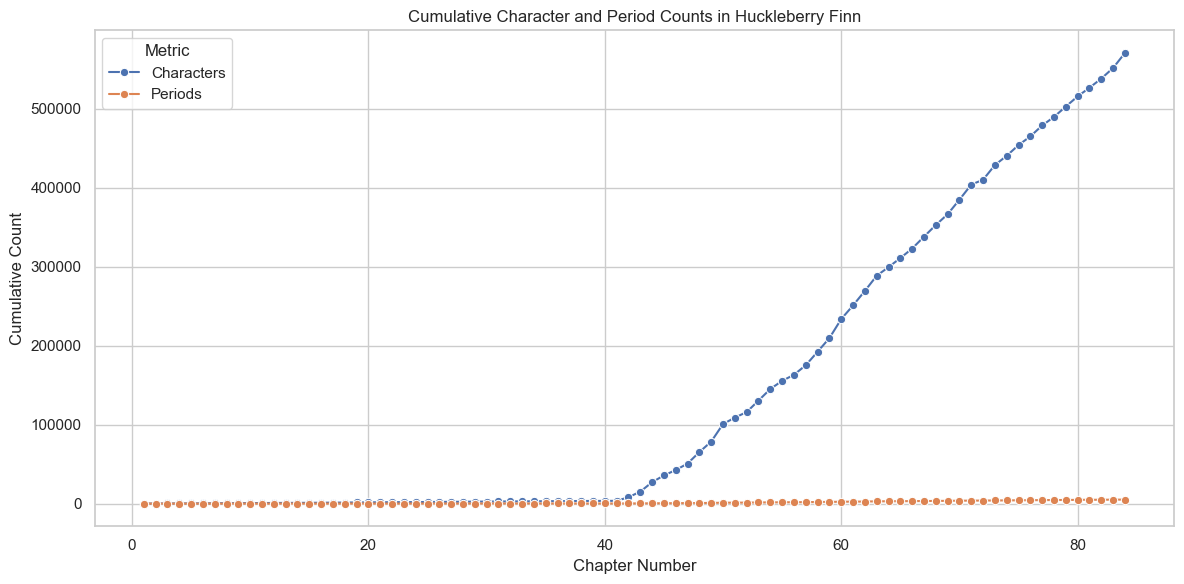

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Sort by Chapter Number
df = df.sort_values('Chapter Number')

# Step 2: Count characters and periods in each chapter
df['Character Count'] = df['Text'].apply(len)
df['Period Count'] = df['Text'].apply(lambda x: x.count('.'))

# Step 3: Compute cumulative counts
df['Cumulative Characters'] = df['Character Count'].cumsum()
df['Cumulative Periods'] = df['Period Count'].cumsum()

# Step 4: Prepare data for plotting
df_plot = df.melt(id_vars='Chapter Number',
                  value_vars=['Cumulative Characters', 'Cumulative Periods'],
                  var_name='Metric',
                  value_name='Cumulative Count')

# Step 5: Clean up metric names
df_plot['Metric'] = df_plot['Metric'].str.replace('Cumulative ', '')

# Step 6: Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='Chapter Number', y='Cumulative Count', hue='Metric', marker='o')

plt.title('Cumulative Character and Period Counts in Huckleberry Finn')
plt.xlabel('Chapter Number')
plt.ylabel('Cumulative Count')
plt.grid(True)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()
